# GANs in R with `torch`: from notation to training

We observe

$$
\{X_1,\ldots,X_n\}, \qquad X_i\in\mathbb{R}^d,
$$

and seek a generator

$$
G_\theta:\mathbb{R}^{d'}\to\mathbb{R}^d
$$

such that, for a latent random vector $Z\sim\pi$,

$$
\widetilde X = G_\theta(Z)\overset{d}{\simeq}X.
$$

A discriminator

$$
D_\phi:\mathbb{R}^d\to[0,1]
$$

tries to distinguish observations from the data distribution from observations produced by the generator.

The classical GAN objective is

$$
\min_{\theta}\max_{\phi}
\left[
\mathbb E_{p_X}\{\log D_\phi(X)\}
+
\mathbb E_{p_Z}\{\log(1-D_\phi(G_\theta(Z)))\}
\right].
$$


## Learning objectives

By the end of the practical you should be able to:

1. identify $X$, $Z$, $G_\theta$, $D_\phi$, $d$, and $d'$ in R `torch` code;
2. construct generator and discriminator neural networks;
3. translate the GAN minimax objective into alternating optimisation steps;
4. train a GAN using the R package `torch`;
5. compare the observed and generated distributions.


In [2]:
library(torch)
library(coro)

SEED <- 123L
set.seed(SEED)
torch_manual_seed(SEED)

device <- if (cuda_is_available()) {
  torch_device("cuda")
} else if (backends_mps_is_available()) {
  torch_device("mps")
} else {
  torch_device("cpu")
}

cat("R torch package version:", as.character(packageVersion("torch")), "\n")
cat("Device:", as.character(device), "\n")


ℹ Additional software needs to be downloaded and installed for torch to work correctly.



Do you want to continue? (Yes/no/cancel)  yes


R torch package version: 0.17.0 
Device: cpu 


# 1. Observed data $X_1,\ldots,X_n$

We use a deliberately simple one-dimensional target distribution so that we can inspect the fit visually.

The GAN is **not** given the density below. It sees only the sampled observations.


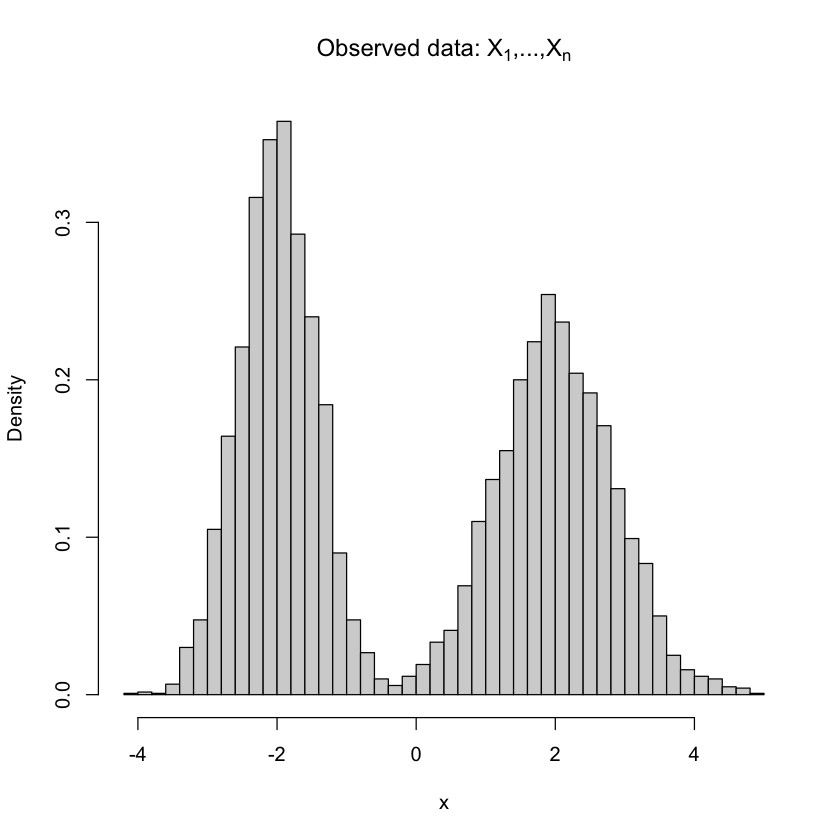

In [3]:
n <- 6000L

component <- torch_bernoulli(
  torch_full(c(n, 1), 0.5)
)

X <- torch_where(
  component == 0,
  -2.0 + 0.55 * torch_randn(c(n, 1)),
   2.0 + 0.85 * torch_randn(c(n, 1))
)

X_plot <- as.numeric(as_array(X))

hist(
  X_plot,
  breaks = 60,
  probability = TRUE,
  main = expression("Observed data: " * X[1] * ",...," * X[n]),
  xlab = expression(x),
  ylab = "Density"
)


# 2. Choose the latent distribution $\pi$

For this example,

$$
d=1,\qquad d'=1,\qquad Z\sim N(0,1).
$$

The latent variable $Z$ provides simple random input. The generator transforms it into a sample that should resemble $X$.


In [4]:
d <- 1L
d_prime <- 1L
J <- 32L

sample_Z <- function(n) {
  torch_randn(
    c(n, d_prime),
    device = device
  )
}

Z <- sample_Z(5L)

cat("Z shape:\n")
print(Z$size())
print(Z)


Z shape:
[1] 5 1
torch_tensor
-0.2528
-0.3453
-1.4593
 0.4159
-1.5746
[ CPUFloatType{5,1} ]


# 3. Construct $G_\theta$ and $D_\phi$

The notation for a one-hidden-layer ReLU generator is

$$
G_\theta^{(m)}(z)
=
\sum_{j=1}^{J}
a_j^{(m)}
\sigma^R\left(
\sum_{i=1}^{d'} w_j^{(i)}z^{(i)}+b_j
\right)
+c^{(m)},
$$

with

$$
\sigma^R(x)=\max(0,x).
$$

In R with `torch`:

- `nn_linear()` contains weights and biases;
- `nn_relu()` applies $\sigma^R$;
- the final `nn_linear()` layer maps to $\mathbb R^d$.

For the practical we use **two hidden ReLU layers** in both networks. 

The discriminator returns a **logit**
$s_\phi(x)\in\mathbb R$.
When needed,

$$
D_\phi(x)=\operatorname{sigmoid}(s_\phi(x)).
$$


In [5]:
Generator <- nn_module(
  "Generator",
  initialize = function() {
    self$net <- nn_sequential(
      nn_linear(d_prime, J),
      nn_relu(),
      nn_linear(J, J),
      nn_relu(),
      nn_linear(J, d)
    )
  },
  forward = function(z) {
    self$net(z)
  }
)

Discriminator <- nn_module(
  "Discriminator",
  initialize = function() {
    self$net <- nn_sequential(
      nn_linear(d, J),
      nn_relu(),
      nn_linear(J, J),
      nn_relu(),
      nn_linear(J, 1)
    )
  },
  forward = function(x) {
    self$net(x)$squeeze(2)
  }
)

G <- Generator()
D <- Discriminator()

G$to(device = device)
D$to(device = device)

cat("Generator G_theta:\n")
print(G)

cat("\nDiscriminator D_phi:\n")
print(D)


Generator G_theta:
An `nn_module` containing 1,153 parameters.

── Modules ─────────────────────────────────────────────────────────────────────
• net: <nn_sequential> #1,153 parameters

Discriminator D_phi:
An `nn_module` containing 1,153 parameters.

── Modules ─────────────────────────────────────────────────────────────────────
• net: <nn_sequential> #1,153 parameters


## Check the dimensions

A batch of latent variables has shape

$$
(\text{batch size},d'),
$$

and the generated data have shape

$$
(\text{batch size},d).
$$


In [6]:
with_no_grad({
  X_tilde <- G(Z)
  prob_real <- torch_sigmoid(D(X_tilde))
})

cat("Z shape:\n")
print(Z$size())

cat("G_theta(Z) shape:\n")
print(X_tilde$size())

cat("D_phi(G_theta(Z)):\n")
print(prob_real)


Z shape:
[1] 5 1
G_theta(Z) shape:
[1] 5 1
D_phi(G_theta(Z)):
torch_tensor
 0.4603
 0.4603
 0.4583
 0.4597
 0.4581
[ CPUFloatType{5} ]


# 4. From the minimax objective to training

Training alternates between two updates. The classical GAN objective is

$$
\min_{\theta}\max_{\phi}
\left[
\mathbb E_{p_X}\{\log D_\phi(X)\}
+
\mathbb E_{p_Z}\{\log(1-D_\phi(G_\theta(Z)))\}
\right].
$$

### Update the discriminator parameters $\phi$

We want

$$
D_\phi(X)\approx1
$$

for real data and

$$
D_\phi(G_\theta(Z))\approx0
$$

for generated data.

### Update the generator parameters $\theta$

Instead of the saturating minimax generator loss,

$$
\min_{\theta}\mathbb E_{p_Z}\left[\{\log(1-D_\phi(G_\theta(Z)))\}
\right],
$$
we use the standard **non-saturating** loss

$$
\mathcal L_G
=
-\mathbb E_{p_Z}
\left[
\log D_\phi(G_\theta(Z))
\right].
$$

This has the same desired equilibrium but provides stronger gradients early in training.

`nn_bce_with_logits_loss()` combines the sigmoid and binary cross-entropy calculations in a numerically stable way.


In [7]:
batch_size <- 128L

loader <- dataloader(
  tensor_dataset(X),
  batch_size = batch_size,
  shuffle = TRUE,
  drop_last = TRUE
)

criterion <- nn_bce_with_logits_loss()

opt_D <- optim_adam(
  D$parameters,
  lr = 2e-4,
  betas = c(0.5, 0.999)
)

opt_G <- optim_adam(
  G$parameters,
  lr = 2e-4,
  betas = c(0.5, 0.999)
)


# 5. Train the GAN

The entire adversarial update is kept in one loop.

The key detail is

```r
x_fake <- G(z)$detach()
```

during the discriminator update: $\phi$ should change, but $\theta$ should not.


In [8]:
epochs <- 100L
history_D <- numeric(epochs)
history_G <- numeric(epochs)

for (epoch in seq_len(epochs)) {
  d_losses <- numeric()
  g_losses <- numeric()

  coro::loop(for (batch in loader) {
    x_real <- batch[[1]]$to(device = device)
    batch_n <- x_real$size(1)

    # --------------------------------
    # 1. Update discriminator phi
    # --------------------------------
    z <- sample_Z(batch_n)
    x_fake <- G(z)$detach()

    real_logits <- D(x_real)
    fake_logits <- D(x_fake)

    loss_D <- (
      criterion(
        real_logits,
        torch_ones_like(real_logits)
      ) +
      criterion(
        fake_logits,
        torch_zeros_like(fake_logits)
      )
    )

    opt_D$zero_grad()  # clear gradients
    loss_D$backward()  # backpropagation
    opt_D$step()       # update

    # --------------------------------
    # 2. Update generator theta
    # --------------------------------
    z <- sample_Z(batch_n)
    x_fake <- G(z)
    fake_logits <- D(x_fake)

    loss_G <- criterion(
      fake_logits,
      torch_ones_like(fake_logits)
    )

    opt_G$zero_grad()
    loss_G$backward()
    opt_G$step()

    d_losses <- c(d_losses, loss_D$item())
    g_losses <- c(g_losses, loss_G$item())
  })

  history_D[epoch] <- mean(d_losses)
  history_G[epoch] <- mean(g_losses)

  if (epoch %% 20 == 0) {
    cat(sprintf(
      "Epoch %3d/%d | loss_D = %.3f | loss_G = %.3f\n",
      epoch, epochs, history_D[epoch], history_G[epoch]
    ))
  }
}


Epoch  20/100 | loss_D = 0.956 | loss_G = 1.120
Epoch  40/100 | loss_D = 1.366 | loss_G = 0.726
Epoch  60/100 | loss_D = 1.379 | loss_G = 0.700
Epoch  80/100 | loss_D = 1.383 | loss_G = 0.699
Epoch 100/100 | loss_D = 1.385 | loss_G = 0.697


# 6. Diagnostics

GAN losses do not behave like an ordinary regression loss: neither is expected simply to decrease to zero.

A useful evaluation combines the training losses with direct comparison of the real and generated samples.


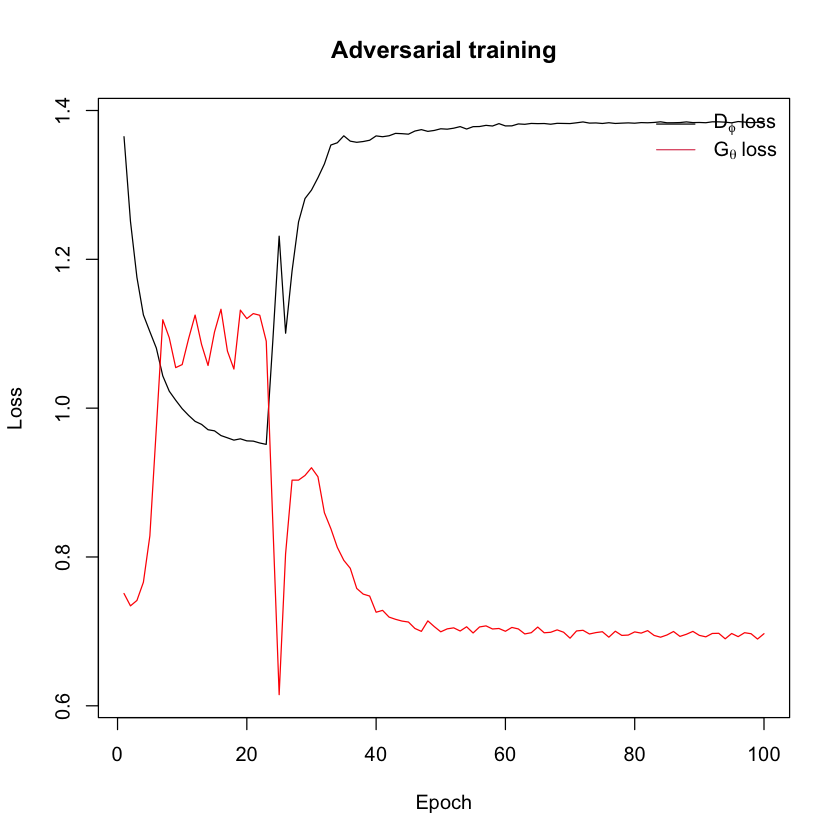

In [11]:
plot(
  history_D,
  type = "l",
  xlab = "Epoch",
  ylab = "Loss",
  main = "Adversarial training",
  ylim = range(c(history_D, history_G))
)
lines(history_G, col="red")
legend(
  "topright",
  legend = c(expression(D[phi]~"loss"), expression(G[theta]~"loss")),
  lty = 1,
  bty = "n",
    col = c(1,2)
)


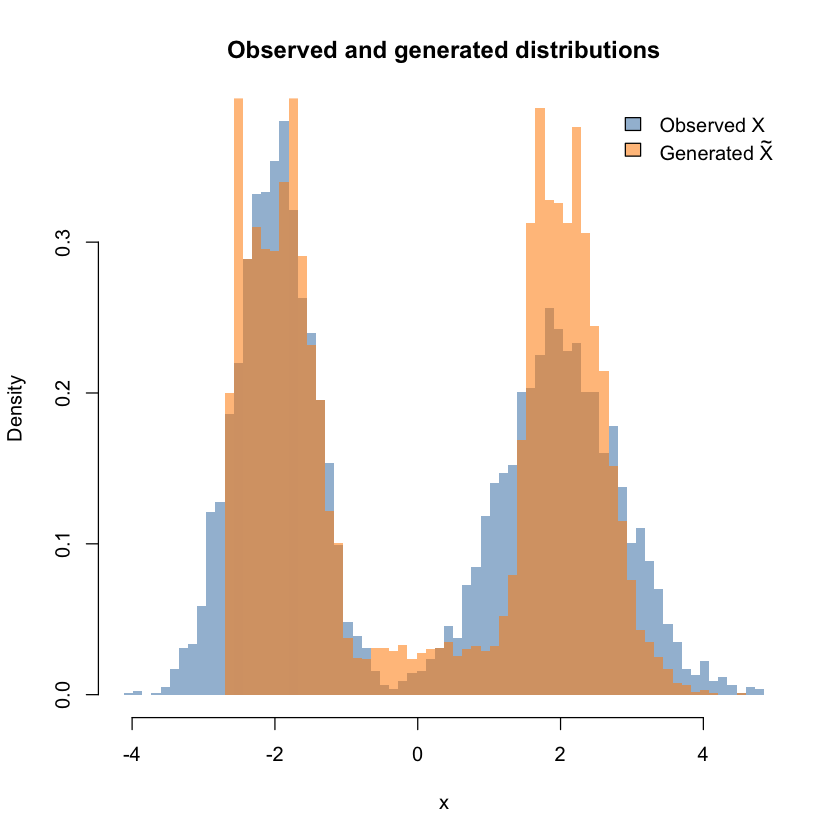

In [12]:
G$eval()

with_no_grad({
  X_fake <- G(
    sample_Z(10000L)
  )$cpu()
})

X_fake <- as.numeric(as_array(X_fake))
X_real <- as.numeric(as_array(X))

x_limits <- range(c(X_real, X_fake))
hist_breaks <- seq(x_limits[1], x_limits[2], length.out = 71)

hist(
  X_real,
  breaks = hist_breaks,
  probability = TRUE,
  col = adjustcolor("steelblue", alpha.f = 0.55),
  border = NA,
  xlab = expression(x),
  ylab = "Density",
  main = "Observed and generated distributions"
)
hist(
  X_fake,
  breaks = hist_breaks,
  probability = TRUE,
  add = TRUE,
  col = adjustcolor("darkorange", alpha.f = 0.55),
  border = NA
)
legend(
  "topright",
  legend = c(expression("Observed " * X),
             expression("Generated " * tilde(X))),
  fill = c(
    adjustcolor("steelblue", alpha.f = 0.55),
    adjustcolor("darkorange", alpha.f = 0.55)
  ),
  bty = "n"
)


## Inspect the learned map $G_\theta$

Because $d=d'=1$, we can plot the generator directly as a function of $z$.


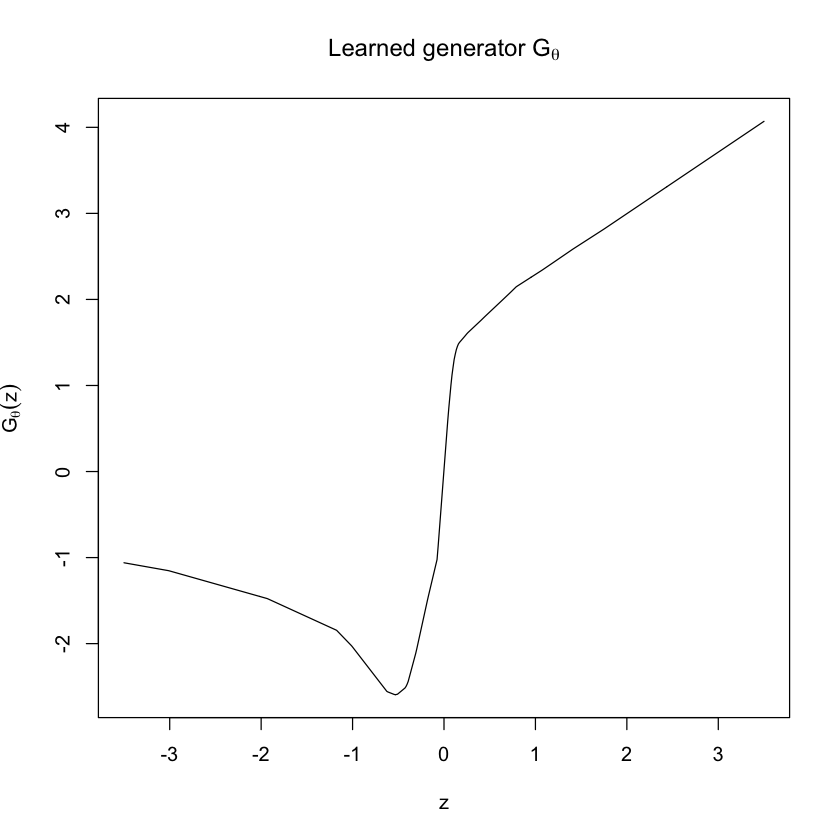

In [13]:
z_grid <- torch_linspace(
  -3.5,
  3.5,
  steps = 600L,
  device = device
)$reshape(c(-1, 1))

with_no_grad({
  g_grid <- G(z_grid)$cpu()
})

plot(
  as.numeric(as_array(z_grid$cpu())),
  as.numeric(as_array(g_grid)),
  type = "l",
  xlab = expression(z),
  ylab = expression(G[theta](z)),
  main = expression("Learned generator " * G[theta])
)


# 7. Discussion and exercises

Try one change at a time.

1. **Latent distribution:** replace $Z\sim N(0,1)$ with $Z\sim U(-1,1)$.
2. **Network width:** change $J$ from 32 to 8 or 128.
3. **Network depth:** remove one hidden layer from $G_\theta$.
4. **Discriminator strength:** give $D_\phi$ two updates for every generator update.
5. **Mode collapse:** repeat training with several random seeds.
6. **Heavy tails:** replace the bimodal data with a Student-$t$ sample and inspect the generated tail.

Questions to discuss:

- What does it mean for the discriminator to become "too good"?
- Why might the generator learn only one mode?
- Why are generated-sample plots often more informative than the raw GAN losses?
- How would you decide whether
  $G_\theta(Z)\overset{d}{\simeq}X$
  is an adequate approximation?


# 8. Extension: a two-dimensional GAN

We now repeat the same construction with

$$
X\in\mathbb R^2.
$$

The aim is to show that the GAN training algorithm is essentially unchanged when we move from one-dimensional to multivariate data. The main changes are the dimensions of the generator and discriminator.

We use a four-mode bivariate distribution and choose

$$
d'=3,\qquad d=2.
$$

The notation and training steps are exactly the same:

$$
Z \sim \pi
\quad\longrightarrow\quad
\widetilde X = G_\theta(Z)
\quad\longrightarrow\quad
D_\phi(\widetilde X).
$$


## 8.1 Simulate observations $X_1,\ldots,X_n\in\mathbb R^2$


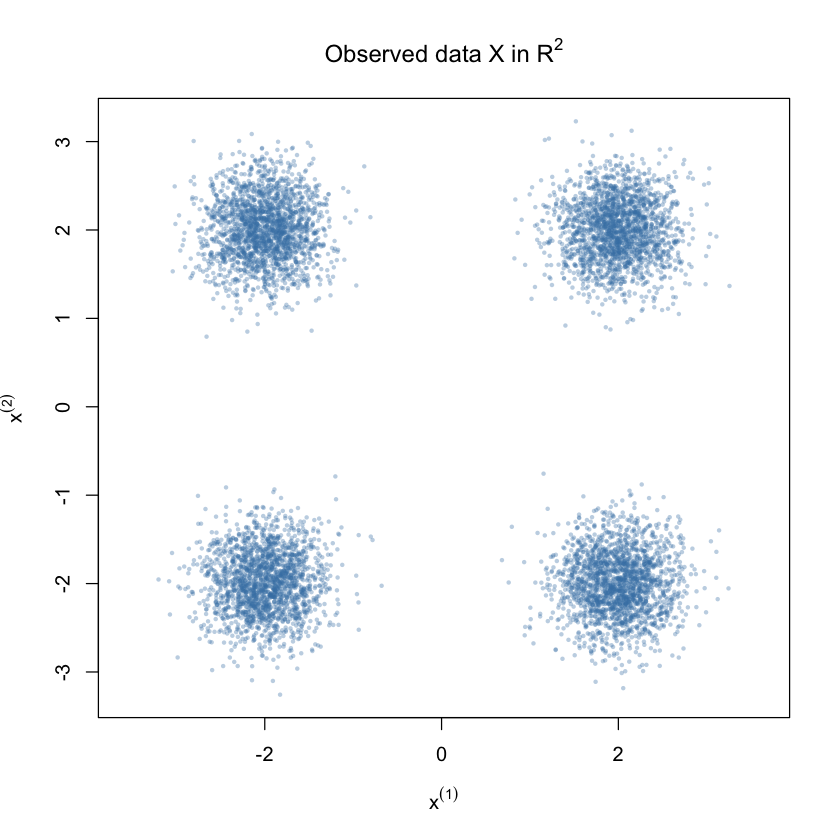

In [14]:
n <- 8000L

centres <- matrix(
  c(
    -2.0, -2.0,
    -2.0,  2.0,
     2.0, -2.0,
     2.0,  2.0
  ),
  ncol = 2,
  byrow = TRUE
)

labels <- sample.int(4, n, replace = TRUE)

X <- torch_tensor(
  centres[labels, , drop = FALSE],
  dtype = torch_float32()
) + 0.35 * torch_randn(c(n, 2))

X_plot <- as_array(X)

plot(
  X_plot[, 1],
  X_plot[, 2],
  pch = 16,
  cex = 0.5,
  col = adjustcolor("steelblue", alpha.f = 0.35),
  xlab = expression(x^{(1)}),
  ylab = expression(x^{(2)}),
  main = expression("Observed data " * X * " in " * R^2),
  asp = 1
)


## 8.2 Generator and discriminator

We choose

$$
d'=3,\qquad d=2.
$$

Thus the generator maps a three-dimensional latent vector into a two-dimensional observation, exactly matching the dimensions in the diagram on p. 7 of Stephane's slides. We use more than $J=4$ hidden units here so that training is easier to observe in a short practical.


In [15]:
d_prime <- 3L
d <- 2L
J <- 64L

Generator <- nn_module(
  "Generator",
  initialize = function() {
    self$net <- nn_sequential(
      nn_linear(d_prime, J),
      nn_relu(),
      nn_linear(J, J),
      nn_relu(),
      nn_linear(J, d)
    )
  },
  forward = function(z) {
    self$net(z)
  }
)

Discriminator <- nn_module(
  "Discriminator",
  initialize = function() {
    self$net <- nn_sequential(
      nn_linear(d, J),
      nn_leaky_relu(negative_slope = 0.2),
      nn_linear(J, J),
      nn_leaky_relu(negative_slope = 0.2),
      nn_linear(J, 1)
    )
  },
  forward = function(x) {
    self$net(x)$squeeze(2)
  }
)

G <- Generator()
D <- Discriminator()

G$to(device = device)
D$to(device = device)

print(G)
print(D)


An `nn_module` containing 4,546 parameters.

── Modules ─────────────────────────────────────────────────────────────────────
• net: <nn_sequential> #4,546 parameters
An `nn_module` containing 4,417 parameters.

── Modules ─────────────────────────────────────────────────────────────────────
• net: <nn_sequential> #4,417 parameters


In [16]:
sample_Z <- function(n) {
  torch_randn(
    c(n, d_prime),
    device = device
  )
}

batch_size <- 256L

loader <- dataloader(
  tensor_dataset(X),
  batch_size = batch_size,
  shuffle = TRUE,
  drop_last = TRUE
)

criterion <- nn_bce_with_logits_loss()

opt_D <- optim_adam(
  D$parameters,
  lr = 2e-4,
  betas = c(0.5, 0.999)
)

opt_G <- optim_adam(
  G$parameters,
  lr = 2e-4,
  betas = c(0.5, 0.999)
)


## 8.3 A compact training loop

Each batch has two phases.

### Phase A: update $\phi$

Maximise the discriminator's ability to separate

$$
X\sim p_X
\quad\text{from}\quad
\widetilde X=G_\theta(Z).
$$

### Phase B: update $\theta$

Change the generator so that the discriminator treats $G_\theta(Z)$ as real.


In [17]:
train_gan <- function(epochs = 250L) {
  history <- list(
    D = numeric(epochs),
    G = numeric(epochs)
  )

  for (epoch in seq_len(epochs)) {
    d_epoch <- numeric()
    g_epoch <- numeric()

    coro::loop(for (batch in loader) {
      x_real <- batch[[1]]$to(device = device)
      batch_n <- x_real$size(1)

      # ---- Update discriminator phi ----
      z <- sample_Z(batch_n)
      x_fake <- G(z)$detach()

      real_logits <- D(x_real)
      fake_logits <- D(x_fake)

      loss_D <- (
        criterion(
          real_logits,
          torch_ones_like(real_logits)
        ) +
        criterion(
          fake_logits,
          torch_zeros_like(fake_logits)
        )
      )

      opt_D$zero_grad()
      loss_D$backward()
      opt_D$step()

      # ---- Update generator theta ----
      z <- sample_Z(batch_n)
      x_fake <- G(z)
      fake_logits <- D(x_fake)

      loss_G <- criterion(
        fake_logits,
        torch_ones_like(fake_logits)
      )

      opt_G$zero_grad()
      loss_G$backward()
      opt_G$step()

      d_epoch <- c(d_epoch, loss_D$item())
      g_epoch <- c(g_epoch, loss_G$item())
    })

    history$D[epoch] <- mean(d_epoch)
    history$G[epoch] <- mean(g_epoch)

    if (epoch %% 30 == 0) {
      cat(sprintf(
        "Epoch %3d/%d | loss_D=%.3f | loss_G=%.3f\n",
        epoch, epochs, history$D[epoch], history$G[epoch]
      ))
    }
  }

  history
}

history <- train_gan()


Epoch  30/250 | loss_D=1.224 | loss_G=0.790
Epoch  60/250 | loss_D=1.285 | loss_G=0.806
Epoch  90/250 | loss_D=1.339 | loss_G=0.770
Epoch 120/250 | loss_D=1.357 | loss_G=0.743
Epoch 150/250 | loss_D=1.362 | loss_G=0.733
Epoch 180/250 | loss_D=1.368 | loss_G=0.728
Epoch 210/250 | loss_D=1.372 | loss_G=0.722
Epoch 240/250 | loss_D=1.374 | loss_G=0.722


## 8.4 Compare real and generated samples


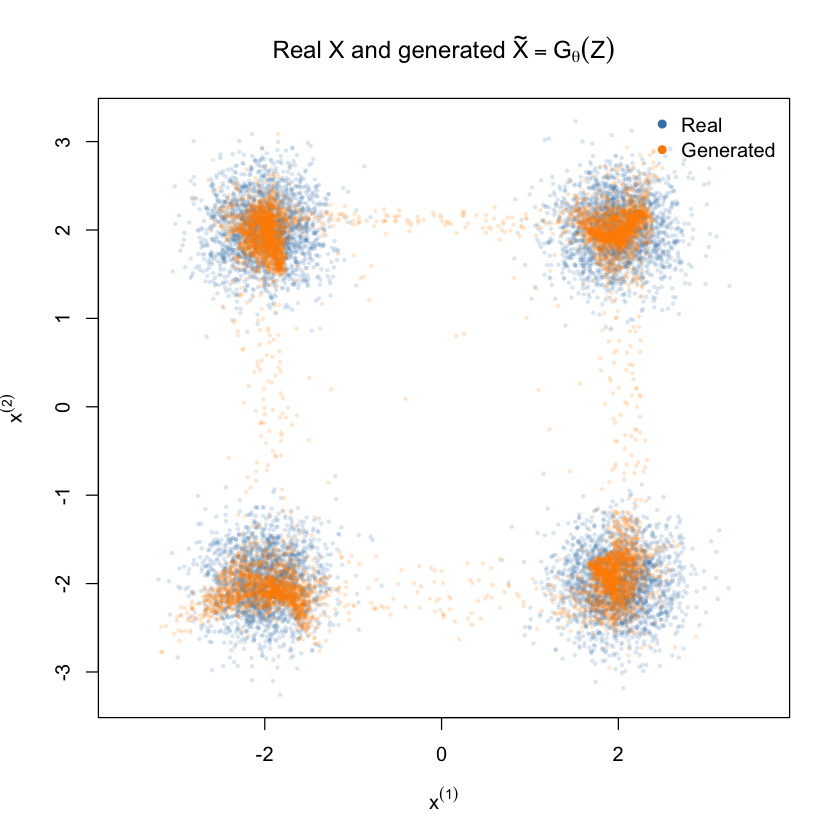

In [18]:
with_no_grad({
  X_fake <- G(sample_Z(8000L))$cpu()
})

X_real_plot <- as_array(X)
X_fake_plot <- as_array(X_fake)

plot(
  X_real_plot[, 1],
  X_real_plot[, 2],
  pch = 16,
  cex = 0.5,
  col = adjustcolor("steelblue", alpha.f = 0.18),
  xlab = expression(x^{(1)}),
  ylab = expression(x^{(2)}),
  main = expression("Real " * X * " and generated " * tilde(X) == G[theta](Z)),
  asp = 1
)
points(
  X_fake_plot[, 1],
  X_fake_plot[, 2],
  pch = 16,
  cex = 0.5,
  col = adjustcolor("darkorange", alpha.f = 0.18)
)
legend(
  "topright",
  legend = c("Real", "Generated"),
  pch = 16,
  col = c("steelblue", "darkorange"),
  bty = "n"
)


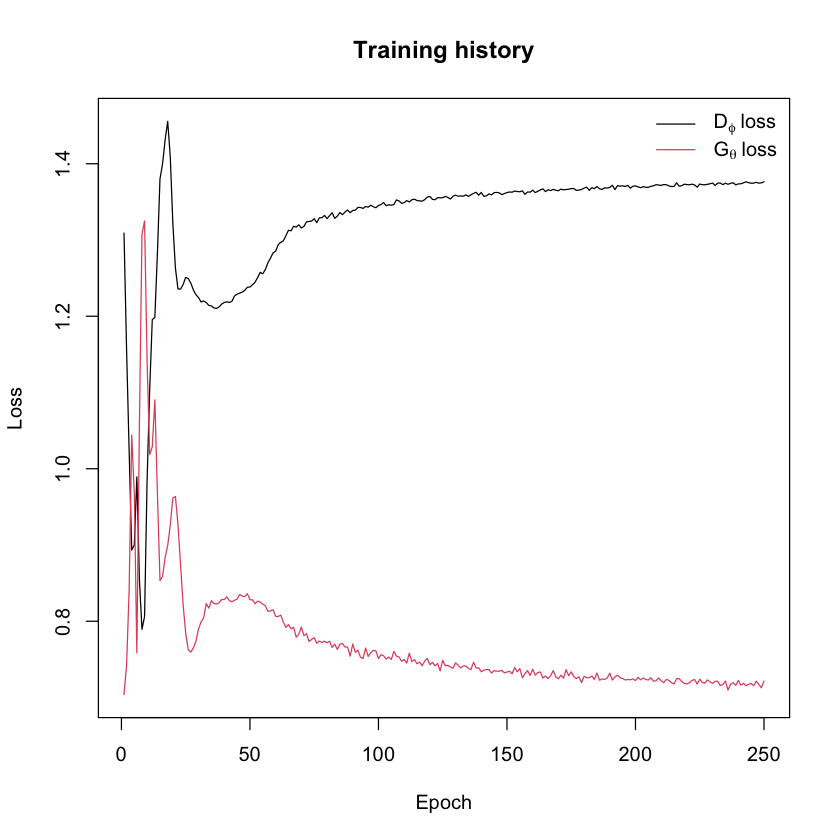

In [20]:
plot(
  history$D,
  type = "l",
  xlab = "Epoch",
  ylab = "Loss",
  main = "Training history",
  ylim = range(c(history$D, history$G))
)
lines(history$G, col = 2)
legend(
  "topright",
  legend = c(expression(D[phi]~"loss"), expression(G[theta]~"loss")),
  lty = 1,
  bty = "n",
    col=c(1,2)
)


## 8.5 Look at the discriminator

A well-balanced GAN should eventually make discrimination difficult. We can inspect $D_\phi(x)$ over a grid.

Values near 1 indicate "real"; values near 0 indicate "generated".


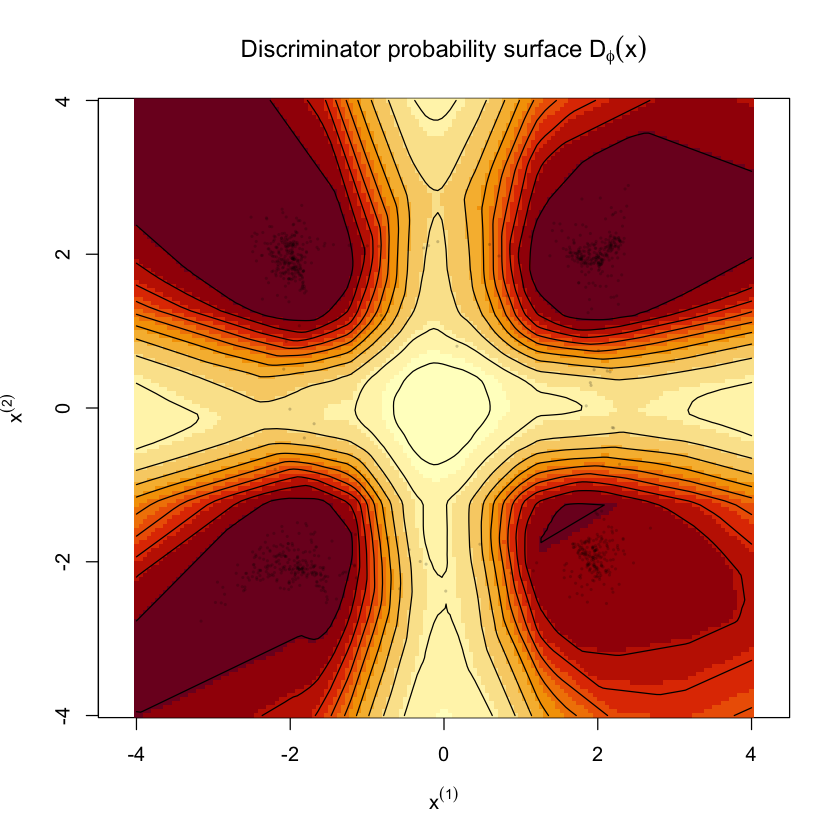

In [21]:
grid_1 <- seq(-4, 4, length.out = 150)
grid_2 <- seq(-4, 4, length.out = 150)

grid_df <- expand.grid(
  x1 = grid_1,
  x2 = grid_2
)

grid <- torch_tensor(
  as.matrix(grid_df),
  dtype = torch_float32(),
  device = device
)

with_no_grad({
  p_real <- torch_sigmoid(D(grid))$cpu()
})

p_real <- matrix(
  as.numeric(as_array(p_real)),
  nrow = length(grid_1),
  ncol = length(grid_2)
)

image(
  grid_1,
  grid_2,
  p_real,
  xlab = expression(x^{(1)}),
  ylab = expression(x^{(2)}),
  main = expression("Discriminator probability surface " * D[phi](x)),
  asp = 1
)
contour(
  grid_1,
  grid_2,
  p_real,
  add = TRUE,
  drawlabels = FALSE
)
points(
  X_fake_plot[1:1000, 1],
  X_fake_plot[1:1000, 2],
  pch = 16,
  cex = 0.35,
  col = adjustcolor("black", alpha.f = 0.2)
)


## 8.6 Workshop experiments

Try these one at a time.

**A. Latent dimension.** Set $d'=1$. Can a one-dimensional latent variable reproduce this two-dimensional distribution well?

**B. Network width.** Set $J=4$, matching the small architecture in the slide diagram. What changes?

**C. Discriminator strength.** Give the discriminator two or three updates for every generator update. Does training improve or become less stable?

**D. Mode collapse.** Repeat training with several random seeds. Does the generator always learn all four modes?

**E. Latent distribution.** Replace the Gaussian $\pi$ with a uniform distribution.

These experiments connect directly to the slide questions: *How should $\pi$ and $d'$ be chosen? How should $G$ be built?*
